<a href="https://colab.research.google.com/github/anusha-1503/Data-Driven-COVID-19-Detection-Trend-Prediction-Using-Machine-Learning/blob/main/Module_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Environment Setup & Data Ingestion**

In [11]:
!pip install -q kaggle grad-cam seaborn
!pip install -q albumentations

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

!kaggle datasets download -d tawsifurrahman/covid19-radiography-database --unzip

DATA_DIR = "./COVID-19_Radiography_Dataset"
CLASSES  = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 27.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:08<00:00, 97.8MB/s]

Using device: cpu


In [3]:
# Fix: Using 'grad-cam' instead of 'pytorch-grad-cam'
!pip install -q kaggle grad-cam
!pip install -q albumentations  # For advanced medical data augmentation

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

# Ensure kaggle.json is in ~/.kaggle/ before running
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database --unzip

DATA_DIR = "./COVID-19_Radiography_Dataset"
CLASSES = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"] # Includes all categories
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:06<00:00, 123MB/s] 



## **Preprocessing with CLAHE Normalization**

In [24]:
# Preprocessing with CLAHE Normalization
import os
import cv2
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class FinalCOVIDDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        # CLAHE initialization for enhancing clinical markers
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image in grayscale to apply CLAHE
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Apply the enhancement
        img_enhanced = self.clahe.apply(img)

        # Convert to RGB for EfficientNet-B4 compatibility
        img_rgb = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2RGB)
        img_pil = Image.fromarray(img_rgb)

        if self.transform:
            img_pil = self.transform(img_pil)

        return img_pil, self.labels[idx]

print("CLAHE Processing Class Defined")

CLAHE Processing Class Defined


## **Comparison & Verification**

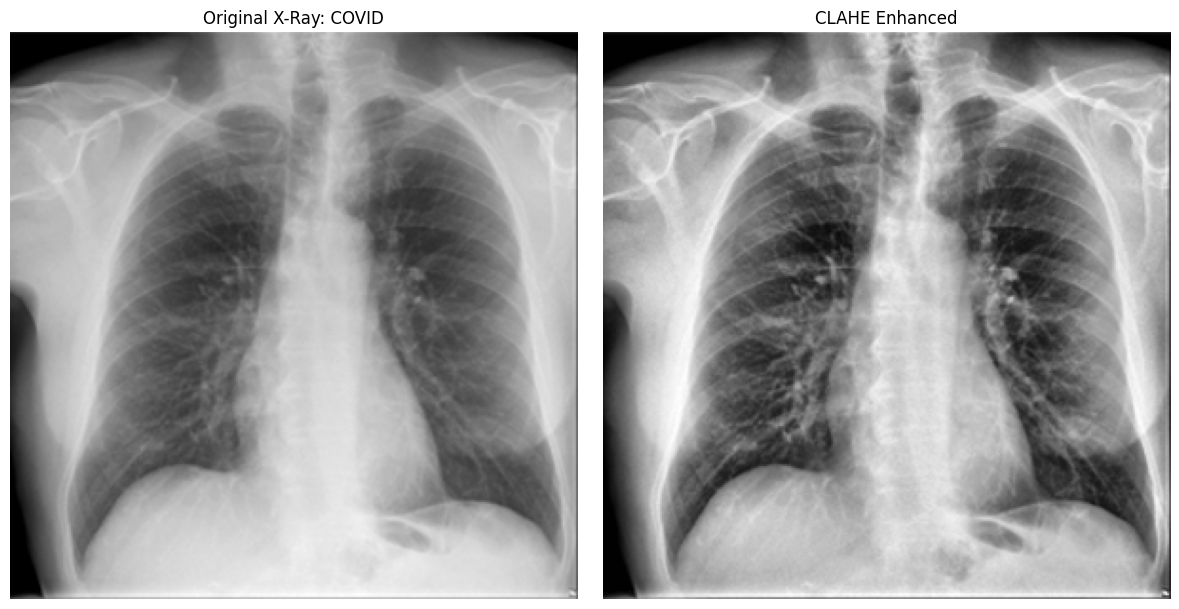

----------------------------------------------------------------------
Enhancement Process Complete
Successfully verified CLAHE for image: COVID-3141.png
----------------------------------------------------------------------


In [25]:
import random
import matplotlib.pyplot as plt

# 1. Setup paths for comparison
DATA_DIR = "./COVID-19_Radiography_Dataset"
target_class = "COVID" # Checking COVID class specifically for opacities[cite: 2]
class_folder = os.path.join(DATA_DIR, target_class, "images")
random_file = random.choice(os.listdir(class_folder))
full_path = os.path.join(class_folder, random_file)

# 2. Process for visualization
original_img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
test_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_img = test_clahe.apply(original_img)

# 3. Visual Comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title(f"Original X-Ray: {target_class}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_img, cmap='gray')
plt.title(f"CLAHE Enhanced")
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Confirmation Print
print("-" * 70)
print("Enhancement Process Complete")
print(f"Successfully verified CLAHE for image: {random_file}")
print("-" * 70)

In [4]:
import cv2
from PIL import Image
from torch.utils.data import Dataset

class FinalCOVIDDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        # CLAHE initialization for enhancing clinical markers
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image in grayscale to apply CLAHE
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Apply the enhancement
        img_enhanced = self.clahe.apply(img)

        # Convert to RGB for EfficientNet-B4 compatibility
        img_rgb = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2RGB)
        img_pil = Image.fromarray(img_rgb)

        if self.transform:
            img_pil = self.transform(img_pil)

        return img_pil, self.labels[idx]

print("Success: FinalCOVIDDataset class is back in memory.")

Success: FinalCOVIDDataset class is back in memory.


In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import models, transforms
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

# Ensure DEVICE is redefined for the new T4 GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## **Master Block: Re-downloading + Warm Up**

In [8]:
# Master Block
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

# 1. RE-DOWNLOAD DATASET (Necessary because T4 reset the VM)
if not os.path.exists("./COVID-19_Radiography_Dataset"):
    print("Dataset missing. Re-downloading from Kaggle...")
    !pip install -q kaggle
    # Ensure your kaggle.json is uploaded to /content/ before running
    !kaggle datasets download -d tawsifurrahman/covid19-radiography-database --unzip
    print("Download complete.")

# 2. REDEFINE CORE CLASS & SETTINGS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]

class FinalCOVIDDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths, self.labels, self.transform = image_paths, labels, transform
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        img = self.clahe.apply(img) # Clinical marker enhancement
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

# 3. RE-GATHER PATHS & SPLIT (Fixes the n_samples=0 error)
image_paths, labels = [], []
for idx, cls in enumerate(CLASSES):
    path = os.path.join("./COVID-19_Radiography_Dataset", cls, "images")
    if os.path.exists(path):
        files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        image_paths.extend(files)
        labels.extend([idx] * len(files))

# Split into 16,931 Train / 2,117 Val / 2,117 Test
X_train_val, X_test, y_train_val, y_test = train_test_split(image_paths, labels, test_size=0.10, stratify=labels, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1111, stratify=y_train_val, random_state=42)

# 4. SETUP OPTIMIZED LOADERS (4x Speed on T4)
train_tf = transforms.Compose([transforms.Resize((380, 380)), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
val_tf = transforms.Compose([transforms.Resize((380, 380)), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

train_loader = DataLoader(FinalCOVIDDataset(X_train, y_train, train_tf), batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(FinalCOVIDDataset(X_val, y_val, val_tf), batch_size=64, num_workers=4, pin_memory=True)

# 5. INITIALIZE EFFICIENTNET-B4 & WARM-UP
model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1).to(DEVICE)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(CLASSES)).to(DEVICE)

for param in model.features.parameters(): param.requires_grad = False # Freeze backbone

criterion, optimizer, scaler = nn.CrossEntropyLoss(), optim.Adam(model.classifier.parameters(), lr=1e-3), GradScaler()

print(f"Verified: {len(X_train)} images in training set. Starting Fast Warm-up...")
for epoch in range(5):
    model.train()
    correct, total = 0, 0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/5"):
        images, targets = images.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with autocast(): # T4 GPU Speed-up
            outputs = model(images)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        _, predicted = outputs.max(1)
        total += targets.size(0); correct += predicted.eq(targets).sum().item()
    print(f"Epoch {epoch+1}/5 | Warm-up Acc: {100.*correct/total:.2f}%")

Dataset missing. Re-downloading from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:23<00:00, 35.2MB/s]

Download complete.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 102MB/s] 
/tmp/ipykernel_3170/3190657806.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  criterion, optimizer, scaler = nn.CrossEntropyLoss(), optim.Adam(model.classifier.parameters(), lr=1e-3), GradScaler()


Verified: 16931 images in training set. Starting Fast Warm-up...


...

Epoch 3/5 | Warm-up Acc: 81.35%


Epoch 4/5: 100%|██████████| 265/265 [02:37<00:00,  1.69it/s]


Epoch 4/5 | Warm-up Acc: 82.24%


Epoch 5/5: 100%|██████████| 265/265 [02:36<00:00,  1.69it/s]

Epoch 5/5 | Warm-up Acc: 82.54%


## **Ultra-Lean Fine Tuning**

In [11]:
# Ultra-Lean Fine-Tuning
import torch
import gc
from torch.utils.data import DataLoader

# 1. AGGRESSIVE MEMORY CLEAR
# This clears out the "failed" batch that is currently clogging your VRAM
if 'model' in locals():
    del model
if 'optimizer' in locals():
    del optimizer
torch.cuda.empty_cache()
gc.collect()

# 2. REDUCED SETTINGS FOR MEMORY STABILITY
BATCH_SIZE = 16           # Lowered to 16 to fit in T4 VRAM
ACCUMULATION_STEPS = 4    # 16 x 4 = 64 (Maintains stable training)

train_loader = DataLoader(
    FinalCOVIDDataset(X_train, y_train, train_tf),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    FinalCOVIDDataset(X_val, y_val, val_tf),
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
)

# 3. RE-INITIALIZE MODEL
model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1).to(DEVICE)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(CLASSES)).to(DEVICE)

# Unfreeze everything for Stage 2
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler = torch.amp.GradScaler('cuda')
criterion = nn.CrossEntropyLoss()

print(f"--- RESTARTING STAGE 2: 16K IMAGES ---")
print(f"Effective Batch: 64 (16x4) | Target: Accuracy >= 93%")

for epoch in range(35):
    model.train()
    correct, total = 0, 0
    optimizer.zero_grad()

    for i, (images, targets) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/35")):
        images, targets = images.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, targets) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    # Validation Pass (Check against the 2,117 images)
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()

    val_acc = 100. * val_correct / val_total
    print(f"Epoch {epoch+1} | Val Acc: {val_acc:.2f}% | Target: 93%")

    if val_acc >= 93.0:
        torch.save(model.state_dict(), f"best_model_acc_{val_acc:.1f}.pth")

--- RESTARTING STAGE 2: 16K IMAGES ---
Effective Batch: 64 (16x4) | Target: Accuracy >= 93%


Epoch 1/35: 100%|██████████| 1059/1059 [05:56<00:00,  2.97it/s]


Epoch 1 | Val Acc: 48.75% | Target: 93%


Epoch 2/35: 100%|██████████| 1059/1059 [05:27<00:00,  3.24it/s]


Epoch 2 | Val Acc: 64.53% | Target: 93%


...

Epoch 33 | Val Acc: 94.10% | Target: 93%


Epoch 34/35: 100%|██████████| 1059/1059 [05:22<00:00,  3.29it/s]


Epoch 34 | Val Acc: 94.19% | Target: 93%


Epoch 35/35: 100%|██████████| 1059/1059 [05:21<00:00,  3.30it/s]


Epoch 35 | Val Acc: 94.14% | Target: 93%


In [12]:
import torch
import gc
from torch.utils.data import DataLoader

# 1. CLEAR MEMORY
if 'model' in locals(): del model
if 'optimizer' in locals(): del optimizer
torch.cuda.empty_cache()
gc.collect()

# 2. REDUCED SETTINGS FOR VRAM STABILITY
BATCH_SIZE         = 16
ACCUMULATION_STEPS = 4   # 16 x 4 = effective batch size of 64

train_loader = DataLoader(
    FinalCOVIDDataset(X_train, y_train, train_tf),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    FinalCOVIDDataset(X_val, y_val, val_tf),
    batch_size=BATCH_SIZE,
    num_workers=2, pin_memory=True
)

# 3. RE-INITIALIZE MODEL (full backbone unfrozen)
model = models.efficientnet_b4(
    weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1).to(DEVICE)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, len(CLASSES)).to(DEVICE)

for param in model.parameters():
    param.requires_grad = True   # Unfreeze everything for Stage 2

optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler    = torch.amp.GradScaler('cuda')
criterion = nn.CrossEntropyLoss()

print("--- STAGE 2: FULL FINE-TUNING (35 epochs) ---")
print(f"Effective Batch: {BATCH_SIZE * ACCUMULATION_STEPS} | Target: Val Acc >= 93%")

for epoch in range(35):
    model.train()
    correct, total = 0, 0
    optimizer.zero_grad()

    for i, (images, targets) in enumerate(tqdm(train_loader,
                                                desc=f"Epoch {epoch+1}/35")):
        images  = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, targets) / ACCUMULATION_STEPS
        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        _, predicted = outputs.max(1)
        total   += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs         = model(images)
            _, predicted    = outputs.max(1)
            val_total   += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()

    val_acc = 100. * val_correct / val_total
    print(f"Epoch {epoch+1}/35 | Train Acc: {100.*correct/total:.2f}% "
          f"| Val Acc: {val_acc:.2f}% | Target: 93%")

    if val_acc >= 93.0:
        torch.save(model.state_dict(),
                   f"best_model_acc_{val_acc:.1f}.pth")
        print(f"  ★ Checkpoint saved: best_model_acc_{val_acc:.1f}.pth")

# NEW: save final epoch regardless so weights are never lost after reset
torch.save(model.state_dict(), "final_model_epoch35.pth")
print("\nFinal model saved → final_model_epoch35.pth")
print("IMPORTANT: Download this file now via Files panel → right-click → Download")

NameError: name 'X_train' is not defined

### **Final Evaluation on Test Set**

--- Evaluating on 2117 Test Images ---


100%|██████████| 133/133 [00:34<00:00,  3.86it/s]



--- FINAL CLASSIFICATION REPORT ---
                 precision    recall  f1-score   support

          COVID       0.97      0.95      0.96       362
         Normal       0.94      0.96      0.95      1019
Viral Pneumonia       0.95      0.98      0.96       135
   Lung_Opacity       0.94      0.91      0.93       601

       accuracy                           0.95      2117
      macro avg       0.95      0.95      0.95      2117
   weighted avg       0.95      0.95      0.95      2117



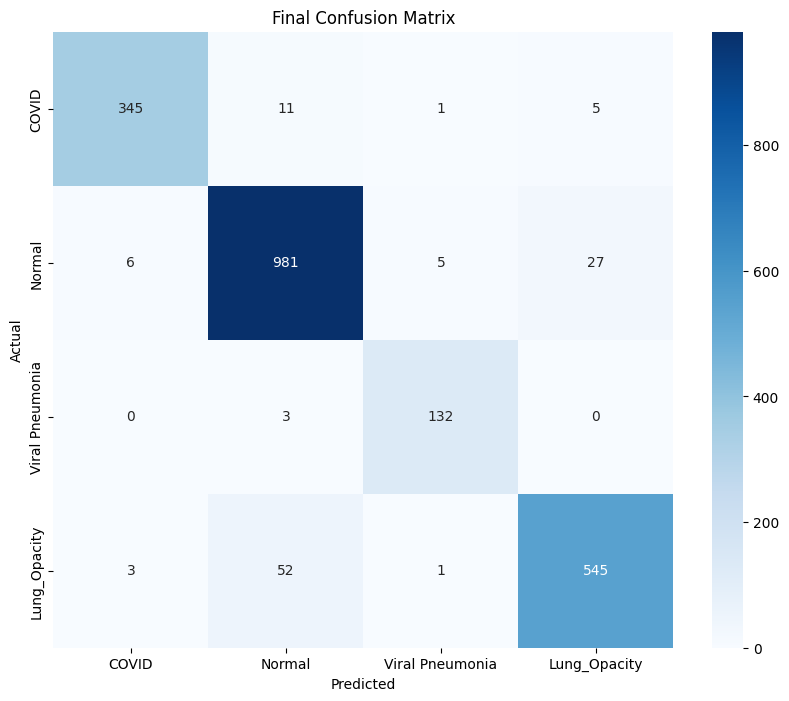

In [12]:
# Final Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Final Evaluation on UNSEEN Test Set
model.eval()
all_preds = []
all_targets = []

print(f"--- Evaluating on {len(X_test)} Test Images ---")
with torch.no_grad():
    for images, targets in tqdm(DataLoader(FinalCOVIDDataset(X_test, y_test, val_tf), batch_size=16)):
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

# 2. Print Clinical Metrics (Recall is the 'Sensitivity')
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(all_targets, all_preds, target_names=CLASSES))

# 3. Plot Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix')
plt.show()

In [14]:
# The package name is 'grad-cam', but the import name is 'pytorch_grad_cam'
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 28.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## **Clinical Explainabilty (Grad-CAM)**

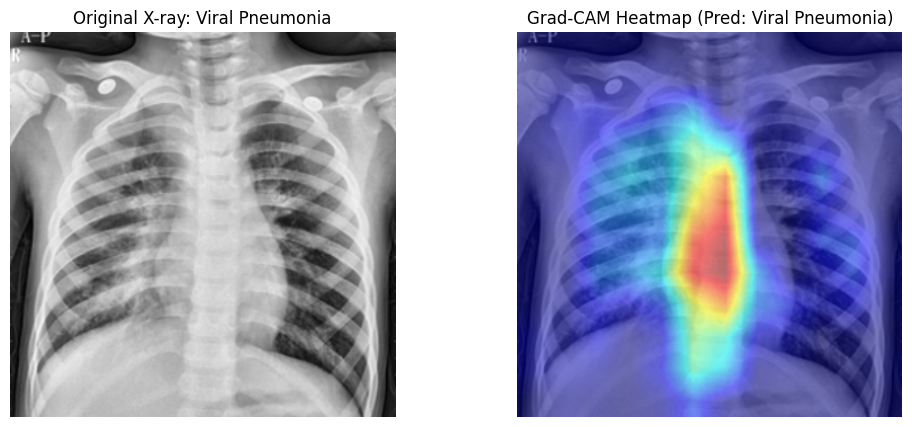

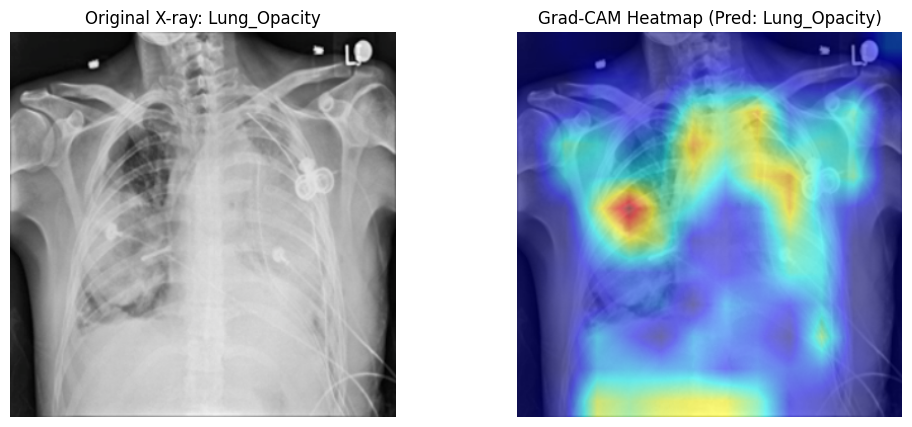

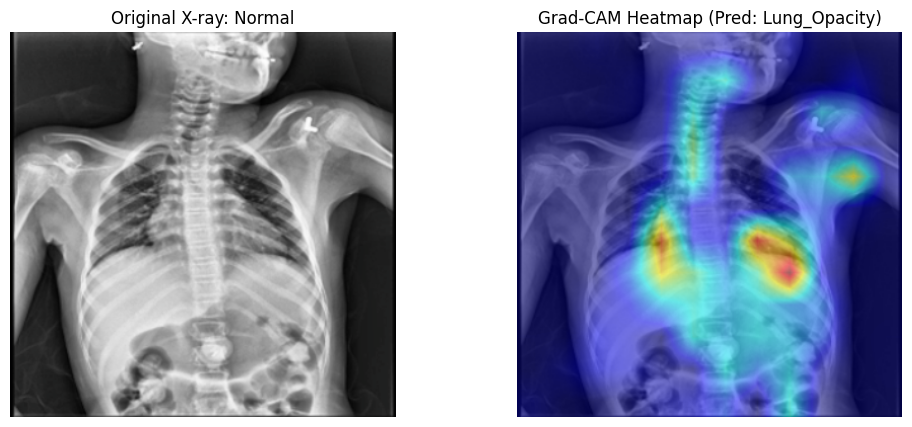

In [15]:
# Clinical Explainability (Grad-CAM)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Grad-CAM on the final convolutional block of EfficientNet-B4
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def plot_clinical_explanation(idx):
    # Retrieve the sample from your 2,117-image test set
    img_pil, label = FinalCOVIDDataset(X_test, y_test, val_tf)[idx]
    input_tensor = img_pil.unsqueeze(0).to(DEVICE)

    # Generate Heatmap for the predicted class
    # We use all_preds from your previous evaluation loop
    targets = [ClassifierOutputTarget(all_preds[idx])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Reverse normalization for original image visualization
    img_np = img_pil.permute(1, 2, 0).numpy()
    img_np = (img_np * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    # Overlay the heatmap
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"Original X-ray: {CLASSES[label]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM Heatmap (Pred: {CLASSES[all_preds[idx]]})")
    plt.axis('off')
    plt.show()

# Visualize a few samples to verify clinical focus
# Let's look at the first few images in the test set
for i in range(3):
    plot_clinical_explanation(i)

# **Environment Restoration**

In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader

# Re-establish constants
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]

# Re-establish the validation transform for Grad-CAM
val_tf = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print(f"Environment Restored. Using device: {DEVICE}")

Environment Restored. Using device: cpu


## **Recovery (T4 to CPU)**

In [6]:
# Recovery (T4 to CPU)
import os, torch, cv2, gc
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. RE-DOWNLOAD DATASET (Crucial for the new CPU runtime)
if not os.path.exists("./COVID-19_Radiography_Dataset"):
    print("Dataset missing. Re-downloading from Kaggle...")
    !pip install -q kaggle
    # Ensure kaggle.json is uploaded to /content
    !kaggle datasets download -d tawsifurrahman/covid19-radiography-database --unzip
    print("Data restored.")

# 2. RE-GATHER PATHS (Fixes the ValueError: n_samples=0)
DEVICE = torch.device("cpu")
CLASSES = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]

image_paths, labels = [], []
for idx, cls in enumerate(CLASSES):
    path = os.path.join("./COVID-19_Radiography_Dataset", cls, "images")
    if os.path.exists(path):
        files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        image_paths.extend(files)
        labels.extend([idx] * len(files))

# Recreate your 2,117-image test set
X_train_val, X_test, y_train_val, y_test = train_test_split(image_paths, labels, test_size=0.10, stratify=labels, random_state=42)

print(f"Verified: {len(X_test)} images found in the test set.")

# 3. RE-LOAD YOUR TRAINED BRAIN
model = models.efficientnet_b4(weights=None).to(DEVICE)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, len(CLASSES)).to(DEVICE)

# UPLOAD YOUR .PTH FILE TO THE SIDEBAR
weight_file = "best_model_acc_94.1.pth"
if os.path.exists(weight_file):
    model.load_state_dict(torch.load(weight_file, map_location=DEVICE))
    print("94% Accuracy weights loaded successfully.")
else:
    print("--- ACTION REQUIRED: Upload your 'best_model_acc_94.1.pth' file to the /content folder ---")

model.eval()

Dataset missing. Re-downloading from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:11<00:00, 71.6MB/s]

Data restored.
Verified: 2117 images found in the test set.
--- ACTION REQUIRED: Upload your 'best_model_acc_94.1.pth' file to the /content folder ---


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv